# “Machine Learning Benchmark for Used Car Price Prediction: Accuracy vs Speed Trade-offs”

## Description

Rusty Bargain is a used car sales service developing an app to attract new customers. Through this app, users can quickly estimate the market value of their car.

Rusty Bargain's business case main goals:

- Prediction quality
- Speed of prediction
- Time required for training


## Results

At the end of the notebook you can find a table of results of the best configuration for each model built, we present two outcomes, the first table presents best model quality and the other is 

## Libraries imports

In [2]:
import pandas as pd
import numpy as np
import time
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.sparse import hstack
from scipy.sparse import csr_matrix

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

## Dataset overview

In [3]:
# Load the dataset
path = r'C:\Users\rodri\OneDrive\Documentos\PANCHO\TripleTen\Proyectos\15_PricePrediction_RustyBargain\car_data.csv'
df = pd.read_csv(path)

display(df.sample(5))

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
3320,24/03/2016 20:52,3700,wagon,2008,manual,136,focus,150000,9,gasoline,ford,no,24/03/2016 00:00,0,38226,01/04/2016 18:47
20907,27/03/2016 23:46,1500,small,2001,NaN,0,polo,150000,8,petrol,volkswagen,no,27/03/2016 00:00,0,20535,05/04/2016 23:16
278560,04/04/2016 14:39,1700,small,2000,auto,55,fortwo,150000,8,petrol,smart,no,04/04/2016 00:00,0,53757,06/04/2016 15:46
202170,04/04/2016 17:38,0,small,1998,manual,75,golf,150000,10,petrol,volkswagen,yes,04/04/2016 00:00,0,36433,06/04/2016 19:17
216722,27/03/2016 15:58,550,small,1998,manual,60,punto,150000,5,petrol,fiat,no,27/03/2016 00:00,0,78532,27/03/2016 16:42


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

In [5]:
df.describe().round(2)

,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.00,354369.00,354369.00,354369.00,354369.00,354369.0,354369.00
mean,4416.66,2004.23,110.09,128211.17,5.71,0.0,50508.69
std,4514.16,90.23,189.85,37905.34,3.73,0.0,25783.10
min,0.00,1000.00,0.00,5000.00,0.00,0.0,1067.00
25%,1050.00,1999.00,69.00,125000.00,3.00,0.0,30165.00
50%,2700.00,2003.00,105.00,150000.00,6.00,0.0,49413.00
75%,6400.00,2008.00,143.00,150000.00,9.00,0.0,71083.00
max,20000.00,9999.00,20000.00,150000.00,12.00,0.0,99998.00


In [6]:
print(df.columns)

Index(['DateCrawled', 'Price', 'VehicleType', 'RegistrationYear', 'Gearbox',
       'Power', 'Model', 'Mileage', 'RegistrationMonth', 'FuelType', 'Brand',
       'NotRepaired', 'DateCreated', 'NumberOfPictures', 'PostalCode',
       'LastSeen'],
      dtype='object')


### Switching coluns to datetime data type

In [7]:

def cambio_fecha(df):
    columnas_fechas = ['DateCreated', 'LastSeen']
    
    for col in columnas_fechas:
        if col in df.columns:
            # ensure string and strip whitespace to avoid parsing issues
            s = df[col].astype(str).str.strip()
            if col == 'LastSeen':
                # LastSeen tiene formato dd/mm/YYYY HH:MM
                df[col] = pd.to_datetime(s, dayfirst=True, format='%d/%m/%Y %H:%M', errors='coerce')
            else:
                df[col] = pd.to_datetime(s, errors='coerce')
    
    return df


df = cambio_fecha(df)
df.info()



C:\Users\rodri\AppData\Local\Temp\ipykernel_29768\1590921246.py:12: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(s, errors='coerce')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   DateCrawled        354369 non-null  object        
 1   Price              354369 non-null  int64         
 2   VehicleType        316879 non-null  object        
 3   RegistrationYear   354369 non-null  int64         
 4   Gearbox            334536 non-null  object        
 5   Power              354369 non-null  int64         
 6   Model              334664 non-null  object        
 7   Mileage            354369 non-null  int64         
 8   RegistrationMonth  354369 non-null  int64         
 9   FuelType           321474 non-null  object        
 10  Brand              354369 non-null  object        
 11  NotRepaired        283215 non-null  object        
 12  DateCreated        354369 non-null  datetime64[ns]
 13  NumberOfPictures   354369 non-null  int64   

## Feature Engineering

In [8]:
df_clean = df.drop(['DateCrawled', 'NumberOfPictures'], axis=1, errors='ignore')
print("Dropped 'DateCrawled' and 'NumberOfPictures' columns.")

df_clean['YearCreated'] = df_clean['DateCreated'].dt.year
df_clean['MonthCreated'] = df_clean['DateCreated'].dt.month


Dropped 'DateCrawled' and 'NumberOfPictures' columns.


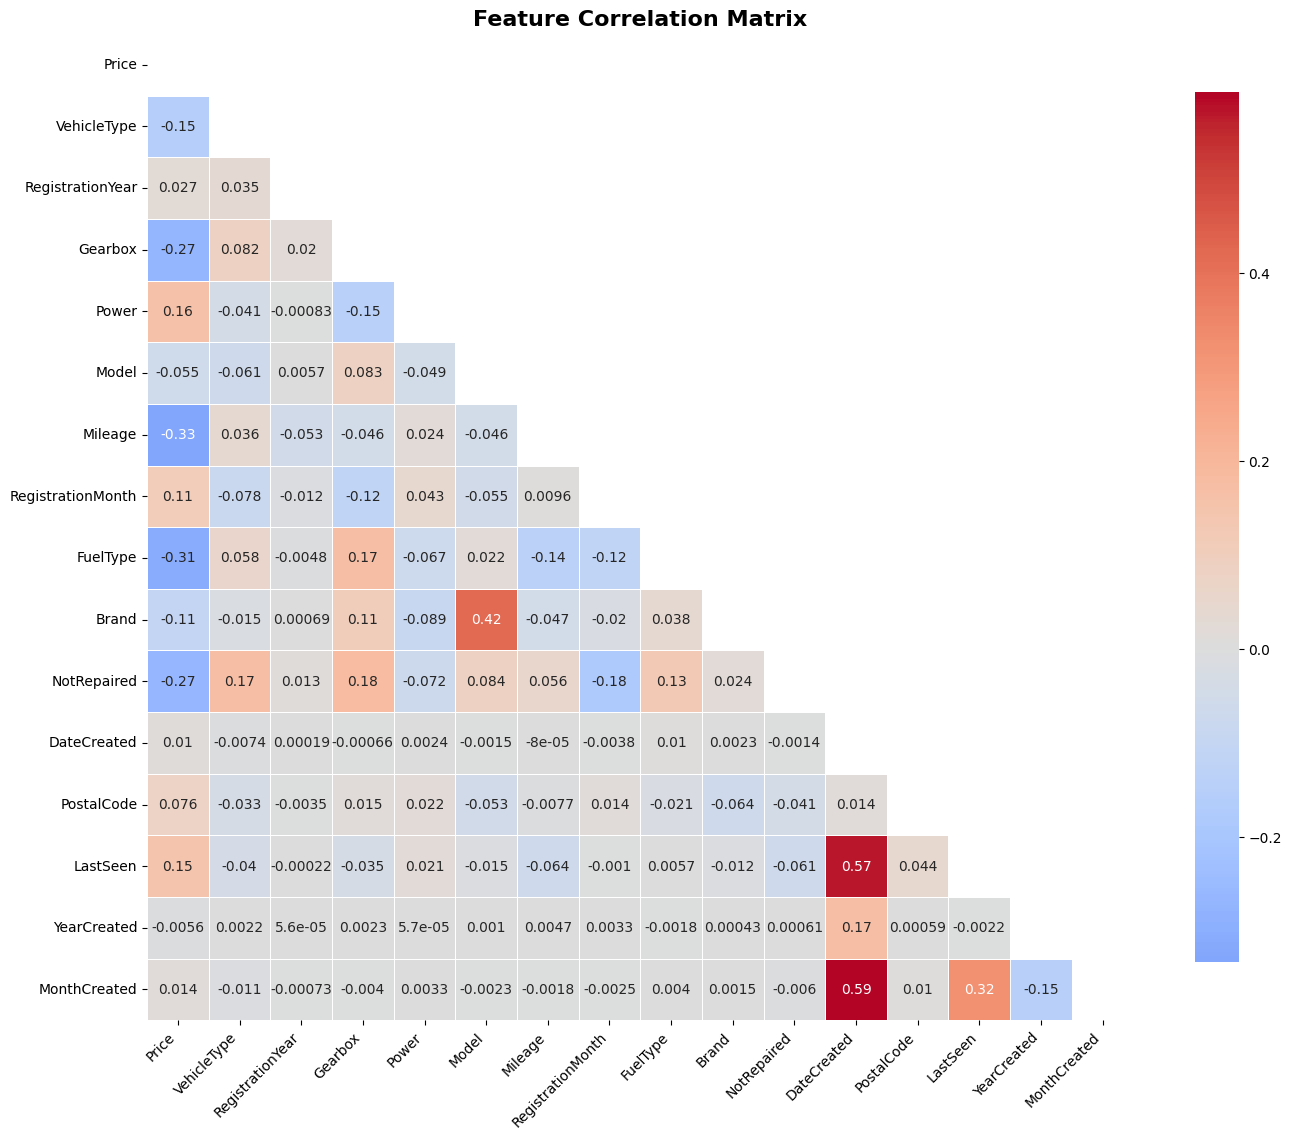

In [9]:
from sklearn.preprocessing import LabelEncoder


cat_features = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'NotRepaired']
num_features = ['YearCreated','MonthCreated','RegistrationYear', 'Power', 'Mileage', 'RegistrationMonth', 'NumberOfPictures', 'PostalCode']

correlation_df =df_clean.copy()

le = LabelEncoder()
for col in cat_features:
    correlation_df[col] = le.fit_transform(correlation_df[col])

plt.figure(figsize=(14, 12))
correlation_matrix = correlation_df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Based on the correlation heatmap between variables, we'll eliminate the column DateCrawled because it's redundat to have it as the correlation it shows is .97, almost 1.

### Missing values

Which columns have missing values to treat.

## Data Preparation

### Split dataset: Train-Test 

We're splitting the dataset into Train dataset and Test dataset to avoid data leackeage.

In [10]:
X = df_clean.drop('Price', axis=1)
y = df_clean['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

Train set: (283495, 15), Test set: (70874, 15)


In [11]:
nulos_train = ((X_train.isnull().sum() / len(X_train)) * 100).round(2)

print("Missing values in Train set:")
print(nulos_train)


Missing values in Train set:
VehicleType          10.58
RegistrationYear      0.00
Gearbox               5.63
Power                 0.00
Model                 5.58
Mileage               0.00
RegistrationMonth     0.00
FuelType              9.32
Brand                 0.00
NotRepaired          20.14
DateCreated           0.00
PostalCode            0.00
LastSeen              0.00
YearCreated           0.00
MonthCreated          0.00
dtype: float64


In [12]:
nulos_test = ((X_test.isnull().sum() / len(X_test)) * 100).round(2)
print("Missing values in Test set:")
print(nulos_test)

Missing values in Test set:
VehicleType          10.57
RegistrationYear      0.00
Gearbox               5.48
Power                 0.00
Model                 5.49
Mileage               0.00
RegistrationMonth     0.00
FuelType              9.12
Brand                 0.00
NotRepaired          19.83
DateCreated           0.00
PostalCode            0.00
LastSeen              0.00
YearCreated           0.00
MonthCreated          0.00
dtype: float64


In [13]:
cat_features = [col for col in X_train.columns if X_train[col].dtype == 'object']
print("Categorical features:", cat_features)

Categorical features: ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'NotRepaired']


In [14]:
num_features = [col for col in X_train.columns if X_train[col].dtype in ['int64', 'float64']]
print("Numerical features:", num_features)

Numerical features: ['RegistrationYear', 'Power', 'Mileage', 'RegistrationMonth', 'PostalCode']


## Missing Values

Handling missing values for each dataset

In [15]:
for col in X_train.columns:
    if X_train[col].isnull().sum() > 0:
        print(f"{col} ({X_train[col].dtype}) has {X_train[col].isnull().sum()} missing values.")


VehicleType (object) has 29997 missing values.
Gearbox (object) has 15951 missing values.
Model (object) has 15811 missing values.
FuelType (object) has 26429 missing values.
NotRepaired (object) has 57101 missing values.


In [16]:
for col in X_test.columns:
    if X_test[col].isnull().sum() > 0:
        print(f"{col} ({X_test[col].dtype}) has {X_test[col].isnull().sum()} missing values.")


VehicleType (object) has 7493 missing values.
Gearbox (object) has 3882 missing values.
Model (object) has 3894 missing values.
FuelType (object) has 6466 missing values.
NotRepaired (object) has 14053 missing values.


In [17]:
def data_handling(df):
    df = df.copy()

    # Rellenar valores faltantes en variables categóricas con 'Unknown'
    df['Gearbox'] = df['Gearbox'].fillna('Unknown')
    df['VehicleType'] = df['VehicleType'].fillna('Unknown')
    df['Model'] = df['Model'].fillna('Unknown')
    df['FuelType'] = df['FuelType'].fillna(df['FuelType'].mode()[0])
    df['NotRepaired'] = df['NotRepaired'].fillna(df['NotRepaired'].mode()[0])
    
    return df

In [18]:
X_train = data_handling(X_train)
X_test = data_handling(X_test)
#y_train = data_handling(y_train)
#y_test = data_handling(X_test)

In [19]:
for col in X_train.columns:
    if X_train[col].isnull().sum() > 0:
        print(f"{col} ({X_train[col].dtype}) has {X_train[col].isnull().sum()} missing values.")


In [20]:
for col in X_test.columns:
    if X_test[col].isnull().sum() > 0:
        print(f"{col} ({X_test[col].dtype}) has {X_test[col].isnull().sum()} missing values.")


Last two cells verifies that there are not any missing values now

In [21]:
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

Train set: (283495, 15), Test set: (70874, 15)


## Scaler and One Hot Encoding

Feature scaling and codification to train our models

In [22]:
scaler = StandardScaler()
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

X_train_scaled = scaler.fit_transform(X_train[num_features])
X_test_scaled = scaler.transform(X_test[num_features])

X_train_ohe = ohe.fit_transform(X_train[cat_features])
X_test_ohe = ohe.transform(X_test[cat_features])


In [23]:
X_train_prep = hstack([
    csr_matrix(X_train_scaled),
    X_train_ohe
])

X_test_prep = hstack([
    csr_matrix(X_test_scaled),
    X_test_ohe
])

We verify the new shape of the dataset, focusing on having the same amount of columns

In [24]:
print("X_train_prep shape:", X_train_prep.shape)
print("X_test_prep shape:", X_test_prep.shape)

X_train_prep shape: (283495, 317)
X_test_prep shape: (70874, 317)


## Model Evaluation

We prepare a function to evaulate our models to then do a paramether tunning for each model

In [25]:
### Evaluacion del modelo

def evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test):
    inicio = time.time()
    modelo.fit(X_train, y_train)
    fin = time.time()

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

    print(f'=== {nombre} ===')
    print(f'Tiempo de entrenamiento: {fin - inicio:.2f} s')
    print(f'RMSE train: {rmse_train:.2f}')
    print(f'RMSE test: {rmse_test:.2f}')
    print()

    return {
        'modelo': nombre,
        'tiempo': fin - inicio,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test
    }

### Linear Regression (base)

In [26]:
resultados = []

linear_regression = LinearRegression()
resultado_lin = evaluar_modelo('Linear Regression', linear_regression, X_train_prep, y_train, X_test_prep, y_test)
resultados.append(resultado_lin)

=== Linear Regression ===
Tiempo de entrenamiento: 4.73 s
RMSE train: 3187.84
RMSE test: 3248.75



In [27]:
print(y.mean())
print(y.median())

4416.656775846645
2700.0


Initially, my model produced unrealistic error values due to improper preprocessing and potential data leakage. After restructuring the pipeline and applying train-test split before transformations, the RMSE dropped significantly to a more realistic level, indicating a more reliable model.

## Decision Tree

In [28]:
mejor_rmse_tree = float('inf')
mejor_params_tree = None

for max_depth in [5,10,20, None]:
    tree = DecisionTreeRegressor(
        random_state = 12345, 
        max_depth = max_depth
    )
    nombre = f'Arbol de Decision (max_depth ={max_depth})'
    
    resultado_tree = evaluar_modelo(
        nombre, 
        tree, 
        X_train_prep,
        y_train,
        X_test_prep,
        y_test
    )
    resultados.append(resultado_tree)

    if resultado_tree['rmse_test'] < mejor_rmse_tree:
        mejor_rmse_tree = resultado_tree['rmse_test']
        mejor_params_tree = {'max_depth': max_depth}

print(f'Mejor Arbol: {mejor_params_tree}, RECM test: {mejor_rmse_tree}')
print()

=== Arbol de Decision (max_depth =5) ===
Tiempo de entrenamiento: 1.73 s
RMSE train: 2548.50
RMSE test: 2584.07

=== Arbol de Decision (max_depth =10) ===
Tiempo de entrenamiento: 9.28 s
RMSE train: 2048.41
RMSE test: 2146.86

=== Arbol de Decision (max_depth =20) ===
Tiempo de entrenamiento: 45.17 s
RMSE train: 1209.23
RMSE test: 2108.91

=== Arbol de Decision (max_depth =None) ===
Tiempo de entrenamiento: 179.81 s
RMSE train: 175.68
RMSE test: 2255.46

Mejor Arbol: {'max_depth': 20}, RECM test: 2108.912993613704



## Random Forest

In [29]:
mejor_rmse_rf = float('inf')
mejor_params_rf = None

for est in [50,100]:
    for max_depth in [10,20]:
        rf = RandomForestRegressor(
            random_state = 12345, 
            max_depth = max_depth, 
            n_estimators = est,
            n_jobs = -1
        )
        nombre = f'Bosque Aleatorio (n_estimators = {est} | depth = {max_depth})'
        
        resultado_rf = evaluar_modelo(
            nombre, 
            rf,
            X_train_prep,
            y_train,
            X_test_prep,
            y_test
        )
        resultados.append(resultado_rf)
    
        if resultado_rf['rmse_test'] < mejor_rmse_rf:
            mejor_rmse_rf = resultado_rf['rmse_test']
            mejor_params_rf = {'n_estimators':est, 'max_depth': max_depth}

print(f'Mejor Bosque Aleatorio: {mejor_params_rf}, RECM test: {mejor_rmse_rf}')
print()

=== Bosque Aleatorio (n_estimators = 50 | depth = 10) ===
Tiempo de entrenamiento: 63.37 s
RMSE train: 1962.98
RMSE test: 2056.22

=== Bosque Aleatorio (n_estimators = 50 | depth = 20) ===
Tiempo de entrenamiento: 269.08 s
RMSE train: 1158.91
RMSE test: 1763.00

=== Bosque Aleatorio (n_estimators = 100 | depth = 10) ===
Tiempo de entrenamiento: 114.54 s
RMSE train: 1961.03
RMSE test: 2053.03

=== Bosque Aleatorio (n_estimators = 100 | depth = 20) ===
Tiempo de entrenamiento: 535.26 s
RMSE train: 1153.29
RMSE test: 1758.05

Mejor Bosque Aleatorio: {'n_estimators': 100, 'max_depth': 20}, RECM test: 1758.0458306206497



## LightGBM

In [30]:

mejor_rmse_lgbm = float('inf')
mejor_params_lgbm = None

for num_leaves in [30, 60]:
    for learning_rate in [0.05, 0.1]:
        lgbm = LGBMRegressor(
            random_state = 12345, 
            n_estimators = 150, 
            num_leaves = num_leaves, 
            learning_rate = learning_rate,
            verbose = -1,
            n_jobs = -1
        )
        nombre = f'LightGBM (num_leaves = {num_leaves} | learning_rate = {learning_rate})'
        
        resultado_lgbm = evaluar_modelo(
            nombre, 
            lgbm, 
            X_train_prep,
            y_train,
            X_test_prep,
            y_test
        )
        resultados.append(resultado_lgbm)
    
        if resultado_lgbm['rmse_test'] < mejor_rmse_lgbm:
            mejor_rmse_lgbm = resultado_lgbm['rmse_test']
            mejor_params_lgbm = {'num_leaves':num_leaves, 'learning_rate': learning_rate}

print(f'Mejor LightGBM: {mejor_params_lgbm}, RECM test: {mejor_rmse_lgbm:.2f}')
print()


C:\Users\rodri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== LightGBM (num_leaves = 30 | learning_rate = 0.05) ===
Tiempo de entrenamiento: 1.26 s
RMSE train: 1855.26
RMSE test: 1901.57



C:\Users\rodri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== LightGBM (num_leaves = 30 | learning_rate = 0.1) ===
Tiempo de entrenamiento: 1.09 s
RMSE train: 1777.78
RMSE test: 1836.67



C:\Users\rodri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== LightGBM (num_leaves = 60 | learning_rate = 0.05) ===
Tiempo de entrenamiento: 1.65 s
RMSE train: 1771.61
RMSE test: 1831.94



C:\Users\rodri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== LightGBM (num_leaves = 60 | learning_rate = 0.1) ===
Tiempo de entrenamiento: 1.50 s
RMSE train: 1691.65
RMSE test: 1782.20

Mejor LightGBM: {'num_leaves': 60, 'learning_rate': 0.1}, RECM test: 1782.20



# Result Summary

In [44]:
res_df = pd.DataFrame(resultados)

# Ver qué columnas tiene
print(res_df.columns)

# Ordenar por rmse_test (de menor a mayor) y reiniciar índice
res_df_sorted = res_df.sort_values(by='rmse_test', ascending=True).reset_index(drop=True)
# Ordenar por tiempo de procesamiento (de menor a mayor) y reiniciar índice
res_df_sorted_time = res_df.sort_values(by='tiempo', ascending=True).reset_index(drop=True)

display(res_df_sorted.head(5).round(2))
print()
display(res_df_sorted_time.head(5).round(2))

Index(['modelo', 'tiempo', 'rmse_train', 'rmse_test'], dtype='object')


,modelo,tiempo,rmse_train,rmse_test
0,Bosque Aleatorio (n_estimators = 100 | depth =...,535.26,1153.29,1758.05
1,Bosque Aleatorio (n_estimators = 50 | depth = 20),269.08,1158.91,1763.00
2,LightGBM (num_leaves = 60 | learning_rate = 0.1),1.50,1691.65,1782.20
3,LightGBM (num_leaves = 60 | learning_rate = 0.05),1.65,1771.61,1831.94
4,LightGBM (num_leaves = 30 | learning_rate = 0.1),1.09,1777.78,1836.67


,modelo,tiempo,rmse_train,rmse_test
0,LightGBM (num_leaves = 30 | learning_rate = 0.1),1.09,1777.78,1836.67
1,LightGBM (num_leaves = 30 | learning_rate = 0.05),1.26,1855.26,1901.57
2,LightGBM (num_leaves = 60 | learning_rate = 0.1),1.50,1691.65,1782.20
3,LightGBM (num_leaves = 60 | learning_rate = 0.05),1.65,1771.61,1831.94
4,Arbol de Decision (max_depth =5),1.73,2548.50,2584.07


In [45]:
res_df['modelo_corto'] = res_df['modelo'].str.replace('Bosque Aleatorio', 'RF')\
                                         .str.replace('LightGBM', 'LGBM')\
                                         .str.replace('Arbol de Decision', 'Tree')\
                                         .str.replace('Linear Regression', 'LR')

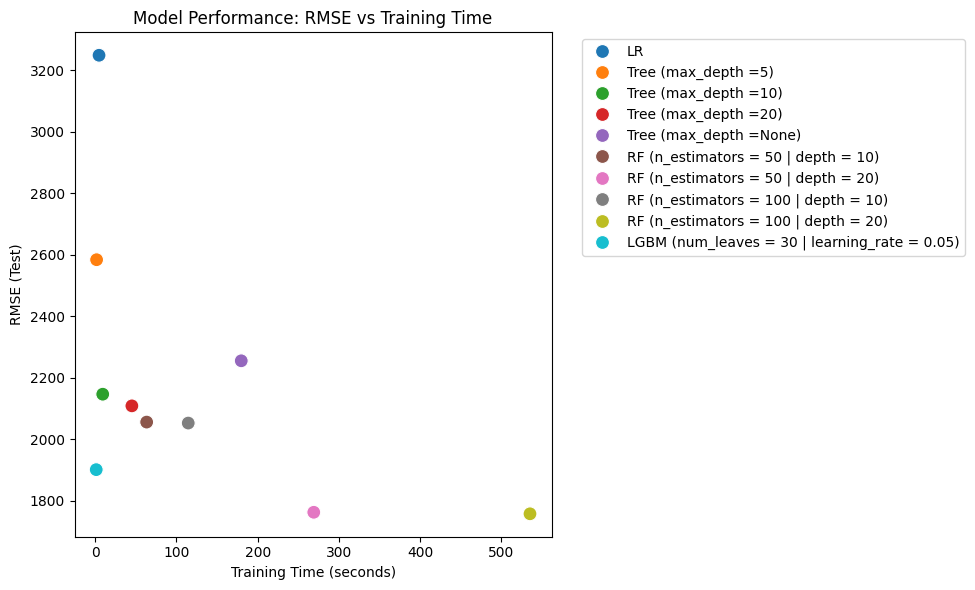

In [46]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=res_df.head(10), #Shows the top 10 models based on time vs rmse
    x='tiempo',
    y='rmse_test',
    hue='modelo_corto',
    s=100
)

plt.title('Model Performance: RMSE vs Training Time')
plt.xlabel('Training Time (seconds)')
plt.ylabel('RMSE (Test)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

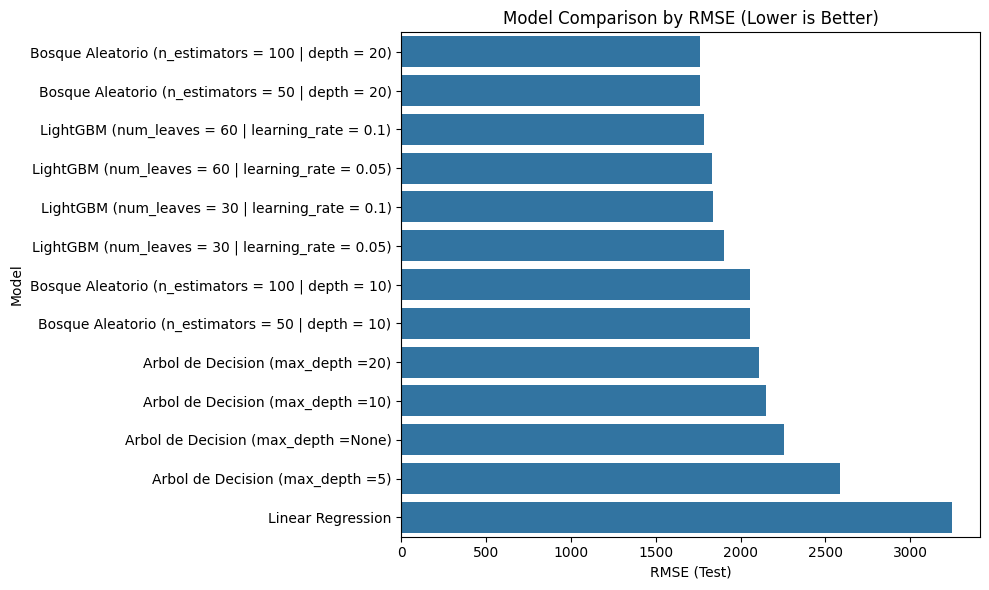

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenar por RMSE (mejor → peor)
rmse_sorted = res_df.sort_values('rmse_test')

plt.figure(figsize=(10,6))

sns.barplot(
    data=rmse_sorted,
    x='rmse_test',
    y='modelo'
)

plt.title('Model Comparison by RMSE (Lower is Better)')
plt.xlabel('RMSE (Test)')
plt.ylabel('Model')

plt.tight_layout()
plt.show()

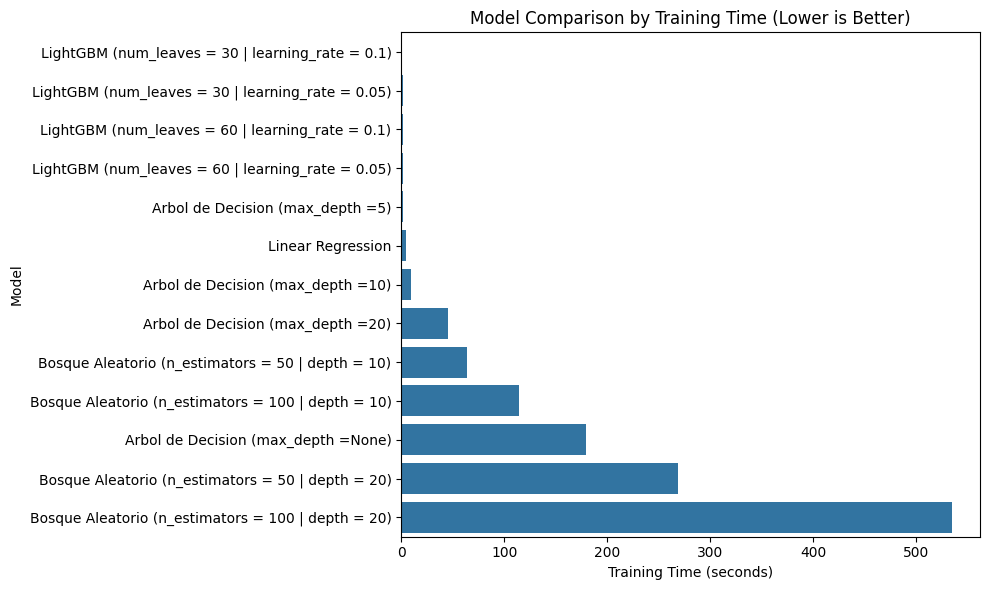

In [48]:
# Ordenar por tiempo (más rápido → más lento)
time_sorted = res_df.sort_values('tiempo')

plt.figure(figsize=(10,6))

sns.barplot(
    data=time_sorted,
    x='tiempo',
    y='modelo'
)

plt.title('Model Comparison by Training Time (Lower is Better)')
plt.xlabel('Training Time (seconds)')
plt.ylabel('Model')

plt.tight_layout()
plt.show()

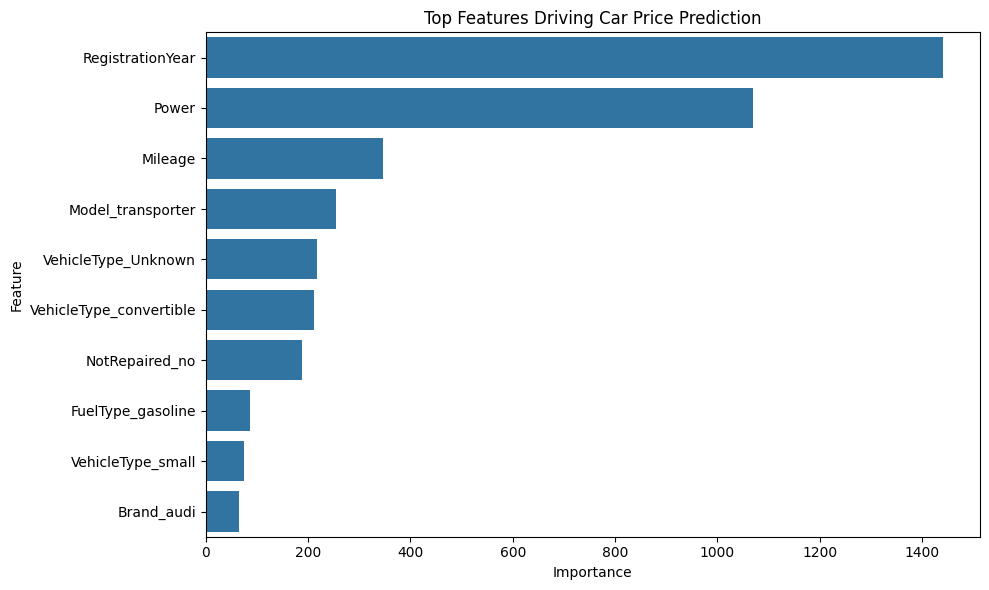

In [ ]:
# nombres de features transformadas
encoded_cat_features = ohe.get_feature_names_out(cat_features).tolist()
all_features = num_features + encoded_cat_features

best_model = LGBMRegressor(random_state = 12345, 
            n_estimators = 150, 
            num_leaves = 30, 
            learning_rate = 0.01,
            verbose = -1,
            n_jobs = -1
        )

best_model.fit(X_train_prep, y_train)

importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

# Top 10
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='importance',
    y='feature'
)

plt.title('Top Features Driving Car Price Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

From a business perspective, the model shows that vehicle usage and technical characteristics are the primary drivers of price. Mileage has a strong negative impact on price, while power and brand-related features contribute positively.

Additionally, the comparison between models highlights an important trade-off: while Random Forest achieves the best accuracy, LightGBM provides a similar level of performance with significantly lower training time.

This makes LightGBM the most suitable model for real-world deployment, where both prediction quality and computational efficiency are critical.